In [1]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from joblib import Parallel, delayed
import os

In [8]:
#参数
def H_onstie(u_N, u_S, t_bian, co):
    return np.array([
    [u_S, 0, -t_bian*1,-co*1],
    [0, -u_S, co*1,     t_bian*1],
    [-t_bian*1, co*1, u_N, 0],
    [-co*1, t_bian*1, 0,     -u_N] ], dtype=complex) 



def H_hop(t_N, t_S, delta_N, delta_S):
    return np.array([
    [-t_S, -delta_S, 0, 0],
    [delta_S, t_S, 0, 0],
    [0, 0, -t_N, -delta_N],
    [0, 0, delta_N, t_N] ], dtype=complex) 

def generate_sequence(n, A, B):
    if n == 0:
        seq = [B]
        return seq, len(seq), 0, 1  # 返回: 序列, 总数, A的数量, B的数量
    elif n == 1:
        seq = [A]
        return seq, len(seq), 1, 0
        
    c_prev2 = [B] 
    c_prev1 = [A]  
    
    # 同步维护 A 和 B 的数量计数
    # count_A_prev1 代表 c_prev1 中 A 的数量，以此类推
    count_A_prev2, count_B_prev2 = 0, 1
    count_A_prev1, count_B_prev1 = 1, 0
    
    for _ in range(2, n + 1):
        current_seq = c_prev1 + c_prev2
        
        # 数量同样按照斐波那契递推规律进行累加
        current_A = count_A_prev1 + count_A_prev2
        current_B = count_B_prev1 + count_B_prev2
        
        # 滚动更新状态
        c_prev2 = c_prev1
        c_prev1 = current_seq
        
        count_A_prev2, count_B_prev2 = count_A_prev1, count_B_prev1
        count_A_prev1, count_B_prev1 = current_A, current_B
        
    return current_seq, len(current_seq), current_A, current_B

def H_old(H_q_list, T_21_list, xshumu):
    d_device = H_q_list[0].shape[0]            
    Z = np.zeros((d_device, d_device), dtype=complex)
    H_DD = [[Z.copy() for _ in range(xshumu)] for _ in range(xshumu)]
    
    for i in range(xshumu):
        H_DD[i][i] = H_q_list[i]  
        
        if i < xshumu - 1:
            H_DD[i][i+1] = T_21_list[i]
            
        if i > 0:
            H_DD[i][i-1] = T_21_list[i-1].conj().T 
    
    H_DD_1=np.block(H_DD)
    return H_DD_1,H_DD

def H(H_q_list, T_21_list, xshumu):
    d_device = H_q_list[0].shape[0] 
    
    # 1. 预分配：直接开辟一整块大内存，默认全为 0
    total_dim = xshumu * d_device
    H_DD_1 = np.zeros((total_dim, total_dim), dtype=complex)
    
    # 2. 切片赋值：直接把小矩阵写进大矩阵对应的位置
    for i in range(xshumu):
        # 当前格点对角块的索引范围
        idx_start = i * d_device
        idx_end = (i + 1) * d_device
        
        # 填入对角块 (On-site)
        H_DD_1[idx_start:idx_end, idx_start:idx_end] = H_q_list[i]
        
        # 填入非对角块 (Hopping)
        if i < xshumu - 1:
            idx_next_end = (i + 2) * d_device
            
            # 右上角：向右跃迁
            H_DD_1[idx_start:idx_end, idx_end:idx_next_end] = T_21_list[i]
            # 左下角：向左跃迁 (共轭转置)
            H_DD_1[idx_end:idx_next_end, idx_start:idx_end] = T_21_list[i].conj().T 
            
    # 因为你之前的调用逻辑是 H_center_matrix, _ = H_old(...)
    # 为了保持接口兼容，第二个返回值直接给 None，省去构建无用二维列表的开销
    return H_DD_1, None


#一般
u_S=2
u_N=2
t_bian=1
co=1

#W_disorder = 0
#random_potentials = np.random.uniform(-W_disorder/2, W_disorder/2, xshumu*cengshu)

#准周期
n=14
_,xshumu, lenA, lenB = generate_sequence(n, 0.2, 0.1)

c_SC=10
p_SC=1
#t_SC_S=c_SC*xshumu/(lenB+p_SC*lenA)
#delta_SC_S=0.3*t_SC_S
delta_SC_S=c_SC*xshumu/(lenB+p_SC*lenA)
t_SC_S=delta_SC_S
zhun_tSC, _, _, _ = generate_sequence(n, t_SC_S*p_SC, t_SC_S)
zhun_deltaSC, _, _, _ = generate_sequence(n, delta_SC_S*p_SC, delta_SC_S)

c_N=0.8
p_N=1
#t_N_S=c_N*xshumu/(lenB+p_N*lenA)
#delta_N_S=0.3*t_N_S
delta_N_S=c_N*xshumu/(lenB+p_N*lenA)
t_N_S=delta_N_S
zhun_tN, _, _, _ = generate_sequence(n, t_N_S*p_N, t_N_S)
zhun_deltaN, _, _, _ = generate_sequence(n, delta_N_S*p_N, delta_N_S)

print(xshumu,lenA, lenB)
print(generate_sequence(n, 'A', 'B')[0])
print(zhun_deltaN)

H_q_list = []
for i in range(xshumu+1):      
    H_q_list.append(H_onstie(u_N, u_S, t_bian, co))

T_21_list=[]
for i in range(xshumu):
    t_N=zhun_tN[i]
    delta_N=zhun_deltaN[i]
    t_S=zhun_tSC[i]
    delta_S=zhun_deltaSC[i]
    T_21_list.append(H_hop(t_N, t_S, delta_N, delta_S))

#输出中间区域矩阵
H_center = H(H_q_list, T_21_list, xshumu+1)

610 377 233
['A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'A', 'B', 'A', 'B', 'A', 'A', 'B', 'A', 'B

In [4]:
# 1. 计算哈密顿量矩阵
H_matrix = H_center[0]
# 2. 对角化求解本征值和本征态
eigenvalues, eigenvectors = np.linalg.eigh(H_matrix)


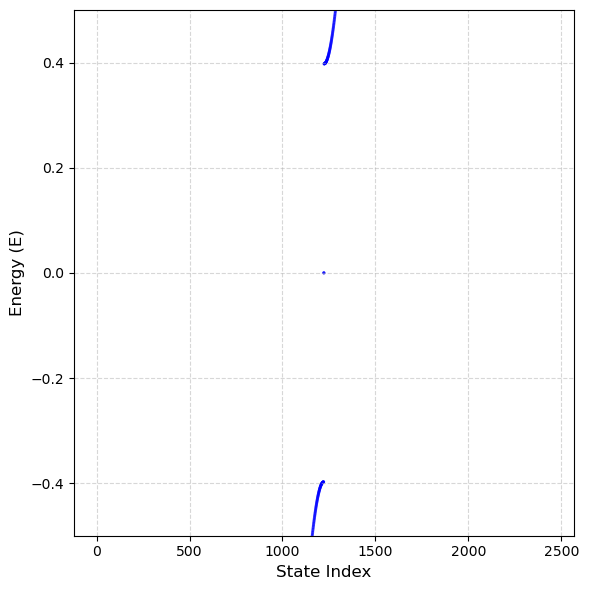

In [5]:
# 图的标准标题定义
fig_title = rf""


# ================= 修改后的 1维 E图 绘制代码 =================
plt.figure(figsize=(6, 6))
# 画法 1：Energy vs State Index (最常用，看能带/能隙最清晰)
# 横坐标是 1 到 N 的索引，纵坐标是能量值
state_indices = np.arange(1,len(eigenvalues)+1)
plt.scatter(state_indices, eigenvalues, c='b', s=5, alpha=0.7, edgecolors='none')

# --- 如果你想看“所有点挤在一条线上”的纯1D分布，可以注释掉上面两行，使用下面这行 ---
# plt.scatter(np.zeros_like(eigenvalues), eigenvalues, c='b', s=5, alpha=0.3, edgecolors='none')
# plt.xlim(-1, 1) # 把横坐标限制住，让点集中在中间

plt.xlabel("State Index", fontsize=12)
plt.ylabel("Energy (E)", fontsize=12)

# 根据需要放开能量区间限.5制，方便看零能附近的态 (比如拓扑边缘态)
plt.ylim(-0.5, 0.5 )
#plt.ylim(-2, 2 )
plt.title(fig_title, fontsize=10, loc='left', pad=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [14]:

def H_onstie(u_N, u_S, t_bian, co):
    return np.array([
    [u_S, 0, -t_bian,-co],
    [0, -u_S, co,     t_bian],
    [-t_bian, co, u_N, 0],
    [-co, t_bian, 0,     -u_N] ], dtype=complex) 


def generate_sequence(n, A, B):
    if n == 0:
        seq = [B]
        return seq, len(seq), 0, 1  # 返回: 序列, 总数, A的数量, B的数量
    elif n == 1:
        seq = [A]
        return seq, len(seq), 1, 0
        
    c_prev2 = [B] 
    c_prev1 = [A]  
    
    # 同步维护 A 和 B 的数量计数
    # count_A_prev1 代表 c_prev1 中 A 的数量，以此类推
    count_A_prev2, count_B_prev2 = 0, 1
    count_A_prev1, count_B_prev1 = 1, 0
    
    for _ in range(2, n + 1):
        current_seq = c_prev1 + c_prev2
        
        # 数量同样按照斐波那契递推规律进行累加
        current_A = count_A_prev1 + count_A_prev2
        current_B = count_B_prev1 + count_B_prev2
        
        # 滚动更新状态
        c_prev2 = c_prev1
        c_prev1 = current_seq
        
        count_A_prev2, count_B_prev2 = count_A_prev1, count_B_prev1
        count_A_prev1, count_B_prev1 = current_A, current_B
        
    return current_seq, len(current_seq), current_A, current_B

def H_hop(t_N, t_S, delta_N, delta_S):
    return np.array([
    [-t_S, delta_S, 0, 0],
    [-delta_S, t_S, 0, 0],
    [0, 0, -t_N, delta_N],
    [0, 0, -delta_N, t_N] ], dtype=complex) 

def H(H_q_list, T_21_list, xshumu):
    d_device = H_q_list[0].shape[0] 
    
    # 1. 预分配：直接开辟一整块大内存，默认全为 0
    total_dim = xshumu * d_device
    H_DD_1 = np.zeros((total_dim, total_dim), dtype=complex)
    
    # 2. 切片赋值：直接把小矩阵写进大矩阵对应的位置
    for i in range(xshumu):
        # 当前格点对角块的索引范围
        idx_start = i * d_device
        idx_end = (i + 1) * d_device
        
        # 填入对角块 (On-site)
        H_DD_1[idx_start:idx_end, idx_start:idx_end] = H_q_list[i]
        
        # 填入非对角块 (Hopping)
        if i < xshumu - 1:
            idx_next_end = (i + 2) * d_device
            
            # 右上角：向右跃迁
            H_DD_1[idx_start:idx_end, idx_end:idx_next_end] = T_21_list[i]
            # 左下角：向左跃迁 (共轭转置)
            H_DD_1[idx_end:idx_next_end, idx_start:idx_end] = T_21_list[i].conj().T 
            
    # 因为你之前的调用逻辑是 H_center_matrix, _ = H_old(...)
    # 为了保持接口兼容，第二个返回值直接给 None，省去构建无用二维列表的开销
    return H_DD_1, None

def build_H_center(p_SC, p_N, n=14, c_SC=10, c_N=0.8, u_S=2, u_N=2, t_bian=1, co=1):
    """
    根据给定的准周期强度 p_SC 和 p_N 生成中间区域的哈密顿量矩阵
    """
    # 1. 生成序列和参数
    _, xshumu, lenA, lenB = generate_sequence(n, 0.2, 0.1)

    delta_SC_S = c_SC * xshumu / (lenB + p_SC * lenA)
    t_SC_S = delta_SC_S
    zhun_tSC, _, _, _ = generate_sequence(n, t_SC_S * p_SC, t_SC_S)
    zhun_deltaSC, _, _, _ = generate_sequence(n, delta_SC_S * p_SC, delta_SC_S)

    delta_N_S = c_N * xshumu / (lenB + p_N * lenA)
    t_N_S = delta_N_S
    zhun_tN, _, _, _ = generate_sequence(n, t_N_S * p_N, t_N_S)
    zhun_deltaN, _, _, _ = generate_sequence(n, delta_N_S * p_N, delta_N_S)

    # 2. 构建 block 矩阵所需的列表
    H_q_list = []
    for i in range(xshumu + 1):      
        H_q_list.append(H_onstie(u_N, u_S, t_bian, co))

    T_21_list = []
    for i in range(xshumu):
        T_21_list.append(H_hop(zhun_tN[i], zhun_tSC[i], zhun_deltaN[i], zhun_deltaSC[i]))

    # 3. 拼接并返回矩阵
    H_center_matrix, _ = H(H_q_list, T_21_list, xshumu + 1)
    return H_center_matrix

def calculate_energy_gap(H_matrix):
    """
    对角化哈密顿量，返回绝对值最小的能量(零能模)和拓扑能隙(体态激发能)
    """
    eigenvalues, eigenvectors = np.linalg.eigh(H_matrix)
    
    # 取绝对值并从小到大排序
    abs_eigenvalues = np.sort(np.abs(eigenvalues))
    
    # 绝对值最小的能量（通常是马约拉纳零能模的有限尺寸劈裂，接近0）
    E_min_abs = abs_eigenvalues[0]
    
    # 拓扑能隙 Delta_g：跳过一对零能模(索引0和1)，取下一个最小的能量
    # (如果系统处于平庸态，没有零能模，这个值依然可以反映能隙大小)
    E_gap = abs_eigenvalues[2] 
    
    return E_min_abs, E_gap

def calculate_energy_gap_1(H_matrix):
    """
    对角化哈密顿量，返回绝对值最小的能量(零能模)和拓扑能隙(体态激发能)
    """
    eigenvalues, eigenvectors = np.linalg.eigh(H_matrix)
    
    # 取绝对值并从小到大排序
    abs_eigenvalues = np.sort(np.abs(eigenvalues))
    
    # 绝对值最小的能量（通常是马约拉纳零能模的有限尺寸劈裂，接近0）
    E_min_abs = abs_eigenvalues[0]
    
    # 拓扑能隙 Delta_g：跳过一对零能模(索引0和1)，取下一个最小的能量
    # (如果系统处于平庸态，没有零能模，这个值依然可以反映能隙大小)
    E_gap = abs_eigenvalues[1] 
    
    return E_min_abs, E_gap

    

<>:29: SyntaxWarning: invalid escape sequence '\D'
<>:35: SyntaxWarning: invalid escape sequence '\D'
<>:29: SyntaxWarning: invalid escape sequence '\D'
<>:35: SyntaxWarning: invalid escape sequence '\D'
C:\Users\taoji\AppData\Local\Temp\ipykernel_39724\3793398181.py:29: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(p_N_values, E_gap_list, marker='o', linestyle='-', color='b', label='Topological Gap $\Delta_g$')
C:\Users\taoji\AppData\Local\Temp\ipykernel_39724\3793398181.py:35: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Energy Gap $\Delta_g$', fontsize=12)


开始计算, 固定 p_SC = 1...
-2.0
-1.6
-1.2
-0.7999999999999998
-0.3999999999999999
0.0
0.40000000000000036
0.8000000000000003
1.2000000000000002
1.6
2.0
计算完成，正在绘制图像...


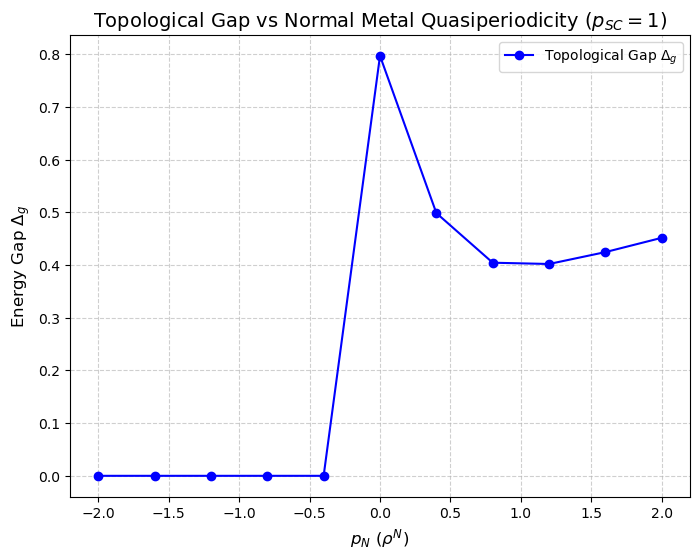

In [18]:
# 设置参数
p_SC_fixed = 1
# 仿照论文，p_N 扫描范围取 0.1 到 3.0，取 30 个点（可根据算力增加点数使曲线更平滑）
p_N_values = np.linspace(-2,2, 11) 

E_min_list = []
E_gap_list = []

print(f"开始计算, 固定 p_SC = {p_SC_fixed}...")

for p_N in p_N_values:
    print(p_N)
    # 1. 生成矩阵
    H_mat = build_H_center(p_SC_fixed, p_N)
    
    # 2. 计算能隙
    E_min, E_gap = calculate_energy_gap(H_mat)
    
    # 3. 记录数据
    E_min_list.append(E_min)
    E_gap_list.append(E_gap)

print("计算完成，正在绘制图像...")

# 绘图
plt.figure(figsize=(8, 6))

# 我们绘制真正的拓扑能隙 \Delta_g，这应该对应论文中的抛物线/凹函数形状
plt.plot(p_N_values, E_gap_list, marker='o', linestyle='-', color='b', label='Topological Gap $\Delta_g$')

# 如果你想对比，也可以把零能模的能量画上去（它应该是一条几乎贴着 0 的线）
# plt.plot(p_N_values, E_min_list, marker='x', linestyle='--', color='r', label='Majorana Splitting (E~0)')

plt.xlabel('$p_N$ ($\\rho^N$)', fontsize=12)
plt.ylabel('Energy Gap $\Delta_g$', fontsize=12)
plt.title(f'Topological Gap vs Normal Metal Quasiperiodicity ($p_{{SC}}={p_SC_fixed}$)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

<>:29: SyntaxWarning: invalid escape sequence '\D'
<>:35: SyntaxWarning: invalid escape sequence '\D'
<>:29: SyntaxWarning: invalid escape sequence '\D'
<>:35: SyntaxWarning: invalid escape sequence '\D'
C:\Users\taoji\AppData\Local\Temp\ipykernel_39724\2854020116.py:29: SyntaxWarning: invalid escape sequence '\D'
  plt.plot(p_N_values, E_gap_list, marker='o', linestyle='-', color='b', label='Topological Gap $\Delta_g$')
C:\Users\taoji\AppData\Local\Temp\ipykernel_39724\2854020116.py:35: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('Energy Gap $\Delta_g$', fontsize=12)


开始计算, 固定 p_SC = 1...
0.0
0.6
1.2
1.7999999999999998
2.4
3.0
计算完成，正在绘制图像...


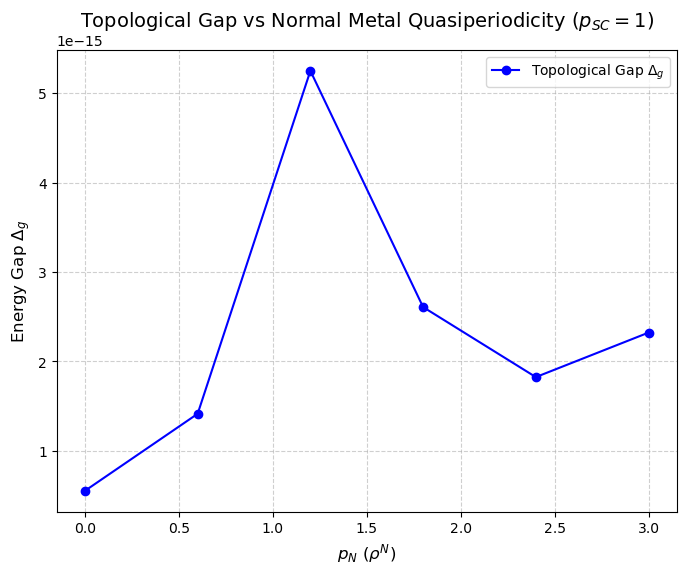

In [16]:
# 设置参数
p_SC_fixed = 1
# 仿照论文，p_N 扫描范围取 0.1 到 3.0，取 30 个点（可根据算力增加点数使曲线更平滑）
p_N_values = np.linspace(0.0,3, 6) 

E_min_list = []
E_gap_list = []

print(f"开始计算, 固定 p_SC = {p_SC_fixed}...")

for p_N in p_N_values:
    print(p_N)
    # 1. 生成矩阵
    H_mat = build_H_center(p_SC_fixed, p_N)
    
    # 2. 计算能隙
    E_min, E_gap = calculate_energy_gap_1(H_mat)
    
    # 3. 记录数据
    E_min_list.append(E_min)
    E_gap_list.append(E_gap)

print("计算完成，正在绘制图像...")

# 绘图
plt.figure(figsize=(8, 6))

# 我们绘制真正的拓扑能隙 \Delta_g，这应该对应论文中的抛物线/凹函数形状
plt.plot(p_N_values, E_gap_list, marker='o', linestyle='-', color='b', label='Topological Gap $\Delta_g$')

# 如果你想对比，也可以把零能模的能量画上去（它应该是一条几乎贴着 0 的线）
# plt.plot(p_N_values, E_min_list, marker='x', linestyle='--', color='r', label='Majorana Splitting (E~0)')

plt.xlabel('$p_N$ ($\\rho^N$)', fontsize=12)
plt.ylabel('Energy Gap $\Delta_g$', fontsize=12)
plt.title(f'Topological Gap vs Normal Metal Quasiperiodicity ($p_{{SC}}={p_SC_fixed}$)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()